# 03b — Listening experiment: frequency, pitch, and the mel scale

This short activity explores why perceptual frequency scales, such as the **mel scale**, are useful in audio analysis.

The goal is not to run a formal psychoacoustic experiment.  
Instead, we will use a simple listening activity to understand the idea that:

```text
same physical difference in Hz ≠ same perceived pitch difference
```

We will generate pure tones, listen to tone pairs, collect simple ratings, and compare linear frequency differences with mel-scale differences.


## Learning goals

By the end of this notebook, students should be able to:

1. Distinguish between **frequency** and **pitch**.
2. Explain why pitch perception is not perfectly linear in Hertz.
3. Listen to tone pairs with equal frequency differences.
4. Compare physical differences in Hz with perceptual distances in mel.
5. Explain why mel filter banks use narrower filters at low frequencies and wider filters at high frequencies.


## Listening safety

Please keep the playback volume low.

Pure tones can be uncomfortable, especially at high frequencies.  
Do not increase the volume to make subtle differences more noticeable.  
If a sound feels uncomfortable, stop playback.

For this activity, the generated tones use a moderate amplitude. Still, listening level depends on headphones, speakers, and computer volume.


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Audio, display


## Frequency and pitch

**Frequency** is a physical quantity.  
It tells us how many oscillations per second a sound wave has, and it is measured in Hertz (Hz).

For example:

```text
200 Hz, 300 Hz, 3000 Hz, 3100 Hz
```

are physical frequencies.

**Pitch** is a perceptual attribute.  
It describes how high or low a sound is perceived by a listener.

In general:

```text
higher frequency → higher perceived pitch
lower frequency → lower perceived pitch
```

However, human pitch perception is not perfectly linear with frequency.

This means that equal differences in Hertz are not necessarily perceived as equal differences in pitch.


## Helper functions

We will synthesize pure sinusoidal tones.

A pure tone can be written as:

$$
x(t) = A \sin(2 \pi f t)
$$

where:

- $A$ is the amplitude,
- $f$ is the frequency in Hz,
- $t$ is time in seconds.


In [2]:
def generate_tone(
    frequency_hz: float,
    duration_s: float = 1.0,
    sampling_rate: int = 22050,
    amplitude: float = 0.15,
):
    """
    Generate a pure sinusoidal tone.

    Parameters
    ----------
    frequency_hz : float
        Frequency of the tone in Hz.
    duration_s : float
        Duration of the tone in seconds.
    sampling_rate : int
        Sampling rate in samples per second.
    amplitude : float
        Tone amplitude.

    Returns
    -------
    tone : np.ndarray
        Generated audio signal.
    sampling_rate : int
        Sampling rate used to synthesize the tone.
    """
    t = np.arange(0, duration_s, 1 / sampling_rate)
    tone = amplitude * np.sin(2 * np.pi * frequency_hz * t)
    return tone, sampling_rate


def concatenate_tone_pair(
    f1: float,
    f2: float,
    duration_s: float = 1.0,
    silence_s: float = 0.4,
    sampling_rate: int = 22050,
    amplitude: float = 0.15,
):
    """
    Concatenate two pure tones separated by a short silence.
    """
    tone_1, sr = generate_tone(f1, duration_s, sampling_rate, amplitude)
    tone_2, sr = generate_tone(f2, duration_s, sampling_rate, amplitude)
    silence = np.zeros(int(silence_s * sr))

    pair = np.concatenate([tone_1, silence, tone_2])
    return pair, sr


## Experiment 1 — Equal differences in Hz

We will compare two tone pairs:

```text
200 Hz → 300 Hz       difference = 100 Hz
3000 Hz → 3100 Hz     difference = 100 Hz
```

Both pairs have exactly the same physical frequency difference: **100 Hz**.

However, the perceived pitch difference is usually more noticeable for the low-frequency pair.


### Low-frequency pair: 200 Hz → 300 Hz

Listen to the two tones.  
After listening, rate how different they sound using this scale:

```text
1 = almost the same
2 = slightly different
3 = clearly different
4 = very different
5 = extremely different
```


In [3]:
low_frequency_pair, sr_tone = concatenate_tone_pair(200, 300)

print("Low-frequency pair: 200 Hz → 300 Hz")
print("Absolute frequency difference:", 300 - 200, "Hz")

display(Audio(low_frequency_pair, rate=sr_tone))


Low-frequency pair: 200 Hz → 300 Hz
Absolute frequency difference: 100 Hz


### High-frequency pair: 3000 Hz → 3100 Hz

Now listen to the high-frequency pair.

Use the same rating scale:

```text
1 = almost the same
2 = slightly different
3 = clearly different
4 = very different
5 = extremely different
```


In [4]:
high_frequency_pair, sr_tone = concatenate_tone_pair(3000, 3100)

print("High-frequency pair: 3000 Hz → 3100 Hz")
print("Absolute frequency difference:", 3100 - 3000, "Hz")

display(Audio(high_frequency_pair, rate=sr_tone))


High-frequency pair: 3000 Hz → 3100 Hz
Absolute frequency difference: 100 Hz


## Record your ratings

Write your personal ratings below.

The goal is not to obtain a perfect answer.  
The goal is to connect what you hear with the idea of a perceptual frequency scale.


In [5]:
ratings = pd.DataFrame(
    {
        "tone_pair": ["200 → 300 Hz", "3000 → 3100 Hz"],
        "physical_difference_hz": [100, 100],
        "perceived_difference_rating_1_to_5": [None, None],
    }
)

ratings


,tone_pair,physical_difference_hz,perceived_difference_rating_1_to_5
0,200 → 300 Hz,100,None
1,3000 → 3100 Hz,100,None


## The mel scale

The mel scale is designed to approximate human pitch perception.

A common formula to convert frequency in Hz to mels is:

$$
m = 2595 \log_{10}\left(1 + \frac{f}{700}\right)
$$

where:

- $f$ is frequency in Hertz,
- $m$ is frequency expressed on the mel scale.

This formula maps linear frequency in Hz to a perceptual frequency scale.


In [6]:
def hz_to_mel(frequency_hz):
    """
    Convert frequency in Hz to mel scale using the common HTK formula.
    """
    return 2595 * np.log10(1 + frequency_hz / 700)


frequency_values = np.array([200, 300, 3000, 3100])
mel_values = hz_to_mel(frequency_values)

mel_table = pd.DataFrame(
    {
        "frequency_hz": frequency_values,
        "mel": mel_values,
    }
)

mel_table


,frequency_hz,mel
0,200,283.229898
1,300,401.970586
2,3000,1876.454060
3,3100,1906.509019


## Compare physical and mel-scale differences

Now let us compare the two tone pairs in Hz and in mels.


In [7]:
pairs = pd.DataFrame(
    {
        "pair": ["200 → 300 Hz", "3000 → 3100 Hz"],
        "f1_hz": [200, 3000],
        "f2_hz": [300, 3100],
    }
)

pairs["difference_hz"] = pairs["f2_hz"] - pairs["f1_hz"]
pairs["f1_mel"] = hz_to_mel(pairs["f1_hz"])
pairs["f2_mel"] = hz_to_mel(pairs["f2_hz"])
pairs["difference_mel"] = pairs["f2_mel"] - pairs["f1_mel"]

pairs


,pair,f1_hz,f2_hz,difference_hz,f1_mel,f2_mel,difference_mel
0,200 → 300 Hz,200,300,100,283.229898,401.970586,118.740688
1,3000 → 3100 Hz,3000,3100,100,1876.454060,1906.509019,30.054959


### Interpretation

Both tone pairs have the same physical frequency difference:

```text
200 Hz → 300 Hz       difference = 100 Hz
3000 Hz → 3100 Hz     difference = 100 Hz
```

However, when these frequencies are converted to the mel scale, the distances are different:

```text
200 Hz → 300 Hz       difference ≈ 118.7 mel
3000 Hz → 3100 Hz     difference ≈ 30.1 mel
```

This means that the 100 Hz difference at low frequencies corresponds to a larger perceptual distance than the same 100 Hz difference at high frequencies.

In short:

```text
same physical difference in Hz ≠ same perceived pitch difference
```


## Visual comparison: Hz scale versus mel scale

The next figure shows the same two tone pairs on two different horizontal axes.

The vertical axis is **not** an acoustic variable.  
It is only used to place the two tone pairs on separate rows.

The important comparison is horizontal:

- left panel: frequency in Hz;
- right panel: frequency converted to mel.


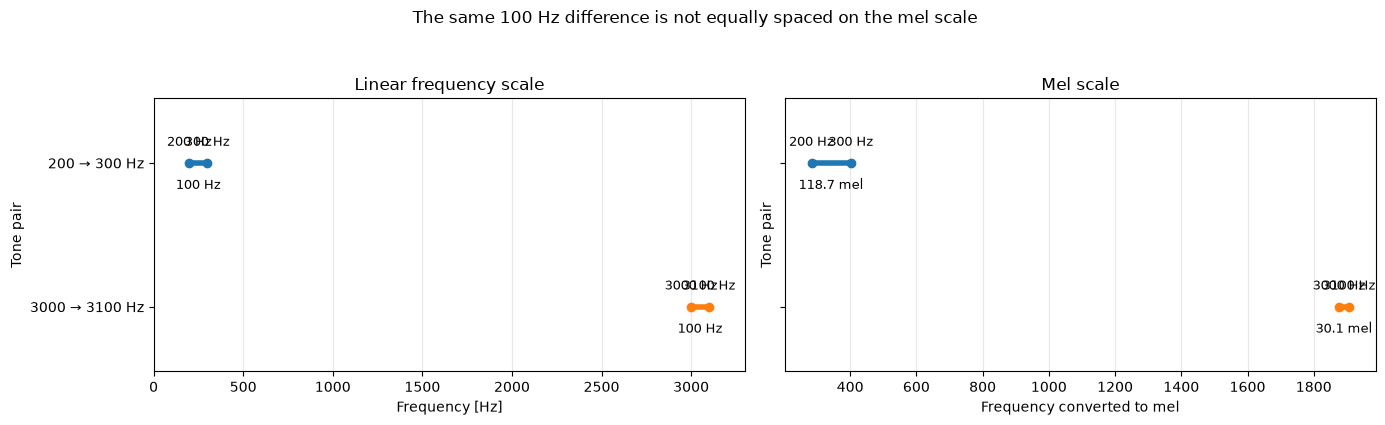

In [8]:
tone_pairs = [
    {
        "label": "200 → 300 Hz",
        "f1": 200,
        "f2": 300,
        "y": 1,
    },
    {
        "label": "3000 → 3100 Hz",
        "f1": 3000,
        "f2": 3100,
        "y": 0,
    },
]

fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=True)

# ------------------------------------------------------------
# Panel 1: Linear frequency scale
# ------------------------------------------------------------
ax = axes[0]

for pair in tone_pairs:
    f1 = pair["f1"]
    f2 = pair["f2"]
    y_pos = pair["y"]

    ax.plot([f1, f2], [y_pos, y_pos], marker="o", linewidth=4)
    ax.text(f1, y_pos + 0.12, f"{f1} Hz", ha="center", fontsize=9)
    ax.text(f2, y_pos + 0.12, f"{f2} Hz", ha="center", fontsize=9)
    ax.text((f1 + f2) / 2, y_pos - 0.18, "100 Hz", ha="center", fontsize=9)

ax.set_title("Linear frequency scale")
ax.set_xlabel("Frequency [Hz]")
ax.set_ylabel("Tone pair")
ax.set_yticks([0, 1])
ax.set_yticklabels(["3000 → 3100 Hz", "200 → 300 Hz"])
ax.set_xlim(0, 3300)
ax.set_ylim(-0.45, 1.45)
ax.grid(True, axis="x", alpha=0.3)

# ------------------------------------------------------------
# Panel 2: Mel scale
# ------------------------------------------------------------
ax = axes[1]

for pair in tone_pairs:
    f1 = pair["f1"]
    f2 = pair["f2"]
    y_pos = pair["y"]

    m1 = hz_to_mel(f1)
    m2 = hz_to_mel(f2)

    ax.plot([m1, m2], [y_pos, y_pos], marker="o", linewidth=4)
    ax.text(m1, y_pos + 0.12, f"{f1} Hz", ha="center", fontsize=9)
    ax.text(m2, y_pos + 0.12, f"{f2} Hz", ha="center", fontsize=9)
    ax.text((m1 + m2) / 2, y_pos - 0.18, f"{m2 - m1:.1f} mel", ha="center", fontsize=9)

ax.set_title("Mel scale")
ax.set_xlabel("Frequency converted to mel")
ax.set_ylabel("Tone pair")
ax.set_yticks([0, 1])
ax.set_yticklabels(["3000 → 3100 Hz", "200 → 300 Hz"])
ax.set_ylim(-0.45, 1.45)
ax.grid(True, axis="x", alpha=0.3)

fig.suptitle("The same 100 Hz difference is not equally spaced on the mel scale", y=1.05)
plt.tight_layout()
plt.show()


### How to read this figure

The horizontal axis is the important axis in this figure.

In the left panel, the horizontal axis shows frequency in Hertz (Hz).  
In the right panel, the horizontal axis shows the same frequencies converted to the mel scale.

The vertical axis does not represent amplitude, time, or energy.  
It is only used to separate the two tone pairs visually:

```text
top row:     200 Hz → 300 Hz
bottom row:  3000 Hz → 3100 Hz
```

On the linear Hz scale, both pairs are separated by exactly 100 Hz.

On the mel scale, the low-frequency pair occupies a larger distance than the high-frequency pair.

This illustrates that equal differences in Hz are not necessarily perceived as equal differences in pitch.


## Why does this matter for mel filter banks?

The mel scale stretches the low-frequency region and compresses the high-frequency region, approximately following human pitch perception.

As a consequence, mel filter banks have the following structure:

- filters are closer together and narrower at low frequencies;
- filters are farther apart and wider at high frequencies.

This gives more frequency resolution where pitch perception is more sensitive to small changes, and less frequency resolution where the same absolute change in Hz is less perceptually salient.

This is one reason why mel-spectrograms are useful in audio analysis.


## Experiment 2 — Frequency ratios

The previous experiment compared equal absolute differences in Hz.

Another useful idea is that pitch perception is often more closely related to **frequency ratios** than to absolute frequency differences.

For example:

```text
200 Hz → 400 Hz       ratio = 2
1000 Hz → 2000 Hz     ratio = 2
```

Both pairs double the frequency.  
Musically, a doubling of frequency corresponds to an octave.


In [9]:
low_ratio_pair, sr_tone = concatenate_tone_pair(200, 400)

print("Frequency ratio pair: 200 Hz → 400 Hz")
print("Frequency ratio:", 400 / 200)
print("Absolute frequency difference:", 400 - 200, "Hz")

display(Audio(low_ratio_pair, rate=sr_tone))


Frequency ratio pair: 200 Hz → 400 Hz
Frequency ratio: 2.0
Absolute frequency difference: 200 Hz


In [10]:
high_ratio_pair, sr_tone = concatenate_tone_pair(1000, 2000)

print("Frequency ratio pair: 1000 Hz → 2000 Hz")
print("Frequency ratio:", 2000 / 1000)
print("Absolute frequency difference:", 2000 - 1000, "Hz")

display(Audio(high_ratio_pair, rate=sr_tone))


Frequency ratio pair: 1000 Hz → 2000 Hz
Frequency ratio: 2.0
Absolute frequency difference: 1000 Hz


### Discussion of frequency ratios

In these examples, the absolute differences are different:

```text
200 Hz → 400 Hz       difference = 200 Hz
1000 Hz → 2000 Hz     difference = 1000 Hz
```

However, both pairs have the same frequency ratio:

```text
ratio = 2
```

This reinforces the idea that pitch perception is not simply based on linear frequency differences in Hz.


## Optional class activity

Each student can write down a perceived-difference rating for each pair.

Then the class can discuss:

1. Which 100 Hz pair sounded more different?
2. Did everyone perceive the same difference?
3. How do the ratings compare with the mel-scale distances?
4. Why might this matter for audio feature extraction?
5. Why might a perceptual scale be useful before machine learning?

This activity connects listening experience with computational audio representations.


## Summary

In this notebook, we explored a simple auditory experiment.

We observed that:

- frequency is a physical quantity measured in Hz;
- pitch is a perceptual attribute;
- equal frequency differences in Hz are not necessarily perceived equally;
- a 100 Hz difference at low frequencies corresponds to a larger mel-scale difference than a 100 Hz difference at high frequencies;
- the mel scale provides more resolution at low frequencies and less resolution at high frequencies;
- this motivates mel filter banks and mel-spectrograms.

This prepares us to better understand why audio data mining often uses perceptually motivated representations such as log-mel-spectrograms and MFCCs.
